# Simulating tibial SSEP data
This notebook defines a simple simulator for tibial SSEP data, which can be used to generate synthetic datasets for testing and benchmarking analysis pipelines. The simulator is designed to be flexible, allowing for different peak shapes, jitter, and noise levels. The core idea is to define a base `Peak` class that models a single SSEP component, and then create child classes that implement specific peak shapes (e.g., Gaussian with rebound, difference-of-exponentials). The main simulation function then combines these peaks with optional jitter and noise to produce realistic synthetic SSEP signals.




In the next cell, we define the base `Peak` class and two child classes: `GaussianReboundPeak` and `DiffExpPeak`. Each class has a `waveform` method that generates the time course of the peak given an array of time points. The main simulation function, `simulate_tibial_ssep_single_trial`, takes a list of peaks and simulates a single trial by summing their waveforms, adding jitter to the latency and amplitude, and optionally adding pink noise.

In [8]:
import numpy as np
from dataclasses import dataclass, field

# ----------------------------
# Base class
# ----------------------------
@dataclass
class Peak:
    name: str
    latency_ms: float
    amp_uv: float
    width_ms: float = 5.0

    def waveform(self, t_ms: np.ndarray) -> np.ndarray:
        return self.amp_uv * np.exp(-0.5 * ((t_ms - self.latency_ms) / self.width_ms) ** 2)


# ----------------------------
# Child 1: Gaussian + rebound
# ----------------------------
@dataclass
class GaussianReboundPeak(Peak):
    width_ms: float = 4.0
    rebound_frac: float = 0.25
    rebound_delay_ms: float = 8.0
    rebound_width_ms: float = 6.0

    def waveform(self, t_ms: np.ndarray) -> np.ndarray:
        main = self.amp_uv * np.exp(-0.5 * ((t_ms - self.latency_ms) / self.width_ms) ** 2)
        rebound = (-self.amp_uv * self.rebound_frac) * np.exp(
            -0.5 * ((t_ms - (self.latency_ms + self.rebound_delay_ms)) / self.rebound_width_ms) ** 2
        )
        return main + rebound


# ----------------------------
# Child 2: Difference-of-exponentials (peak time = latency_ms)
# ----------------------------
@dataclass
class DiffExpPeak(Peak):
    tau_rise_ms: float = 1.0
    tau_decay_ms: float = 8.0

    def waveform(self, t_ms: np.ndarray) -> np.ndarray:
        tr, td = self.tau_rise_ms, self.tau_decay_ms
        if td <= tr:
            raise ValueError(f"{self.name}: tau_decay_ms must be > tau_rise_ms")

        dt = t_ms - self.latency_ms
        y = np.zeros_like(t_ms, dtype=float)

        m = dt >= 0
        d = dt[m]

        raw = np.exp(-d / td) - np.exp(-d / tr)

        d_star = (tr * td / (td - tr)) * np.log(td / tr)
        raw_max = np.exp(-d_star / td) - np.exp(-d_star / tr)

        y[m] = self.amp_uv * (raw / raw_max)
        return y


# ----------------------------
# Simulator: now peak-agnostic
# ----------------------------
def simulate_tibial_ssep_single_trial(
        fs=5000,
        tmin_ms=-20.0,
        tmax_ms=120.0,
        peaks=None,
        latency_jitter_ms=0.6,
        amp_jitter_frac=0.10,
        noise_rms_uv=0.0,
        rng_seed=None,
        add_ringing=False,
):
    rng = np.random.default_rng(rng_seed)
    t_ms = np.arange(tmin_ms, tmax_ms, 1000.0 / fs)
    sig = np.zeros_like(t_ms, dtype=float)

    for p in peaks:
        # trial jitter: make a shallow copy with jittered params
        lat = p.latency_ms + rng.normal(0, latency_jitter_ms)
        amp = p.amp_uv * (1.0 + rng.normal(0, amp_jitter_frac))

        # copy object while preserving its class + extra fields
        p_trial = type(p)(**{**p.__dict__, "latency_ms": lat, "amp_uv": amp})
        sig += p_trial.waveform(t_ms)

    if noise_rms_uv > 0:
        sig += rng.normal(0, noise_rms_uv, size=len(t_ms))

    return t_ms, sig

In the following cell we will define some filtering functions that can be used to process the simulated data. These include a simple low-pass filter and a band-pass filter, which can be applied to the simulated SSEP signals to mimic typical preprocessing steps in real data analysis pipelines. The filters are implemented using Butterworth designs, and we will use the `scipy.signal` library for the actual filtering operations. Importantly, these filters are zero-phase (using `filtfilt`) to avoid introducing any phase distortion, which is crucial for preserving the temporal characteristics of the SSEP peaks.

In [2]:
# defining some simple filters for processing the simulated data
from scipy.signal import butter, filtfilt

def lowpass_filter(data, fs, cutoff_hz=200.0, order=4):
    b, a = butter(order, cutoff_hz / (0.5 * fs), btype="low")
    return filtfilt(b, a, data)

def bandpass_filter(data, fs, low_hz=1.0, high_hz=200.0, order=4):
    b, a = butter(order, [low_hz / (0.5 * fs), high_hz / (0.5 * fs)], btype="band")
    return filtfilt(b, a, data)



In the next cell we will define a class called preprocessor that can be used to apply a sequence of preprocessing steps to the simulated SSEP data. This class will allow us to easily apply multiple filters and other transformations in a consistent way. The `Preprocessor` class will have methods for adding filters to the processing pipeline, as well as a method for applying the entire pipeline to a given signal. This design allows for flexibility in how we preprocess the simulated data, and makes it easy to experiment with different combinations of filters and parameters.

In [20]:
from dataclasses import dataclass, asdict
from typing import Any

@dataclass
class ProcessingStep:
    name: str
    params: dict[str, Any]

class Preprocessor:
    def __init__(self, fs: int):
        self.fs = fs
        self.steps: list[ProcessingStep] = []

    def add_lowpass(self, cutoff_hz: float = 200.0, order: int = 4):
        self.steps.append(
            ProcessingStep("lowpass", {"cutoff_hz": cutoff_hz, "order": order})
        )

    def add_bandpass(self, low_hz: float = 1.0, high_hz: float = 200.0, order: int = 4):
        self.steps.append(
            ProcessingStep("bandpass", {"low_hz": low_hz, "high_hz": high_hz, "order": order})
        )

    def apply(self, data):
        for step in self.steps:
            data = self._apply_step(step, data)
        return data

    def _apply_step(self, step: ProcessingStep, data):
        if step.name == "lowpass":
            return lowpass_filter(data, self.fs, **step.params)
        if step.name == "bandpass":
            return bandpass_filter(data, self.fs, **step.params)
        raise ValueError(f"Unknown step: {step.name}")

    def describe(self):
        # JSON-friendly list of dicts
        return [asdict(s) for s in self.steps]

    @classmethod
    def from_description(cls, fs: int, steps_desc: list[dict[str, Any]]):
        """
        Rebuild a Preprocessor from something previously returned by describe().
        """
        p = cls(fs)
        for d in steps_desc:
            p.steps.append(ProcessingStep(name=d["name"], params=d["params"]))
        return p


#small sanity check to make sure the preprocessor can be created and applied without errors
prep = Preprocessor(fs=5000)
prep.add_bandpass(10, 200)
prep.add_lowpass(150, order=2)

print(prep.describe())
desc = prep.describe()
# save desc somewhere (JSON, file, inside Dataset, etc.)

prep2 = Preprocessor.from_description(fs=5000, steps_desc=desc)
print(prep2.describe())


[{'name': 'bandpass', 'params': {'low_hz': 10, 'high_hz': 200, 'order': 4}}, {'name': 'lowpass', 'params': {'cutoff_hz': 150, 'order': 2}}]
[{'name': 'bandpass', 'params': {'low_hz': 10, 'high_hz': 200, 'order': 4}}, {'name': 'lowpass', 'params': {'cutoff_hz': 150, 'order': 2}}]


#In the next cell we will define a class called preprocessor that can be used to apply a sequence of preprocessing steps to the simulated SSEP data. This class will allow us to easily apply multiple filters and other transformations in a consistent way. The `Preprocessor` class will have methods for adding filters to the processing pipeline, as well as a method for applying the entire pipeline to a given signal. This design allows for flexibility in how we preprocess the simulated data, and makes it easy to experiment with different combinations of filters and parameters.In this cell we define a class called dataset that can be used to generate and store multiple simulated trials of tibial SSEP data. The `Dataset` class takes a list of peaks and simulation parameters, and has a method called `generate_trials` that creates a specified number of trials by calling the `simulate_tibial_ssep_single_trial` function for each trial. The generated data is stored in a list of tuples, where each tuple contains the time points and the corresponding signal for that trial. This class provides a convenient way to manage and access the simulated dataset for further analysis or testing of processing pipelines.

Generated 300 trials with 700 time points each.
First trial time range: -20.0 ms to 119.7999999999995 ms
First trial signal snippet: [-3.90207036 -2.60435899  0.25568083 -0.63248516 -0.03360228 -1.70608782
  1.75879599  1.55558392  0.13206145  2.25448247] ...


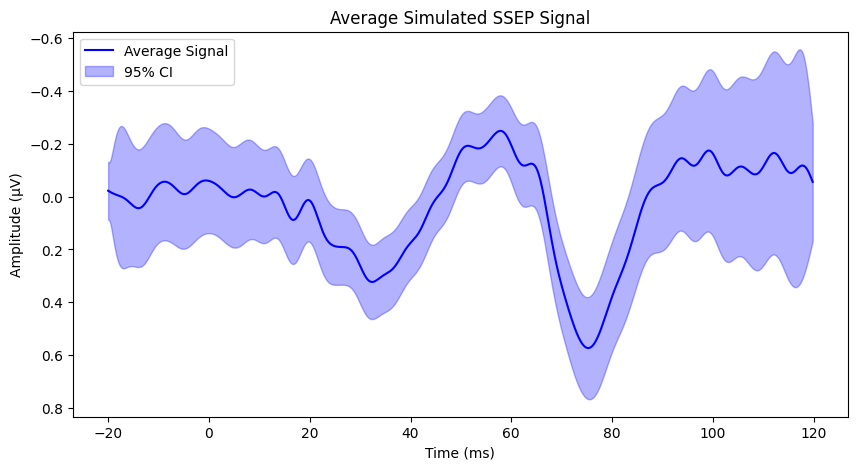

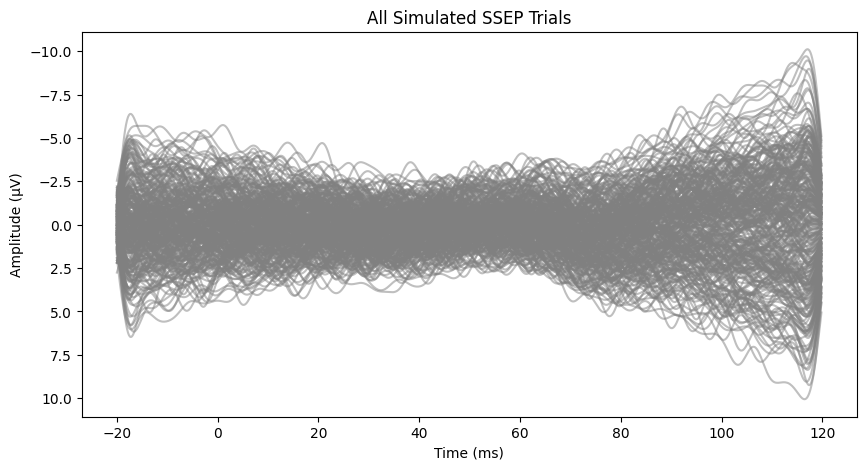

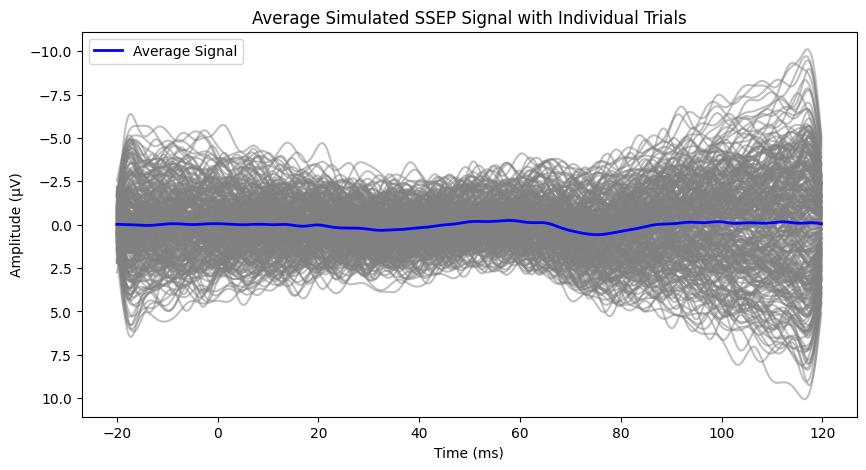

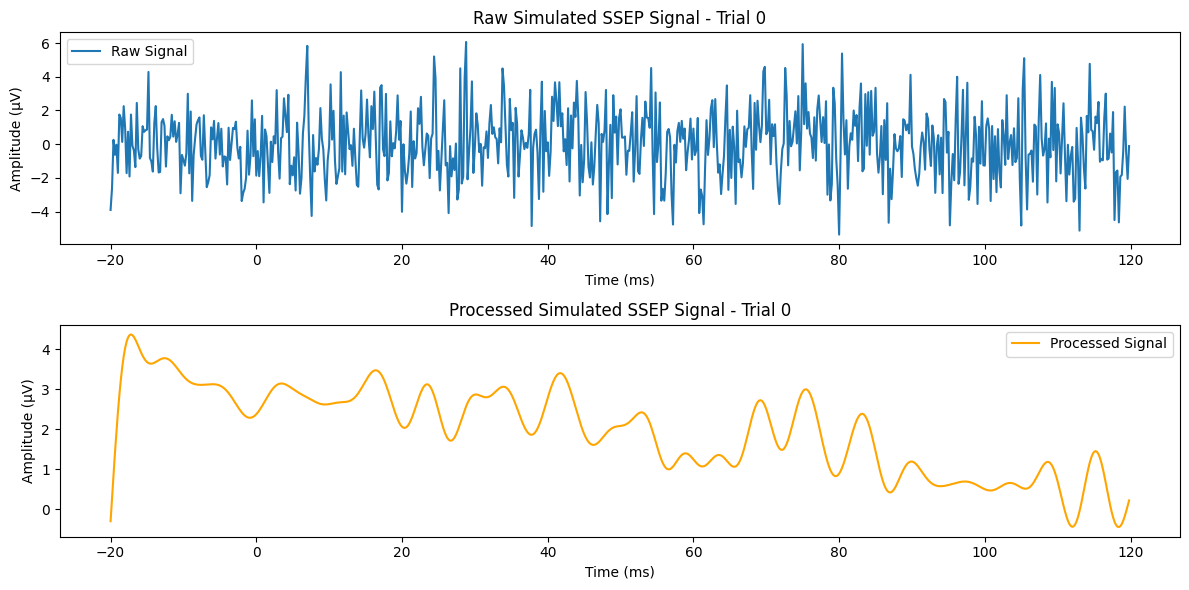

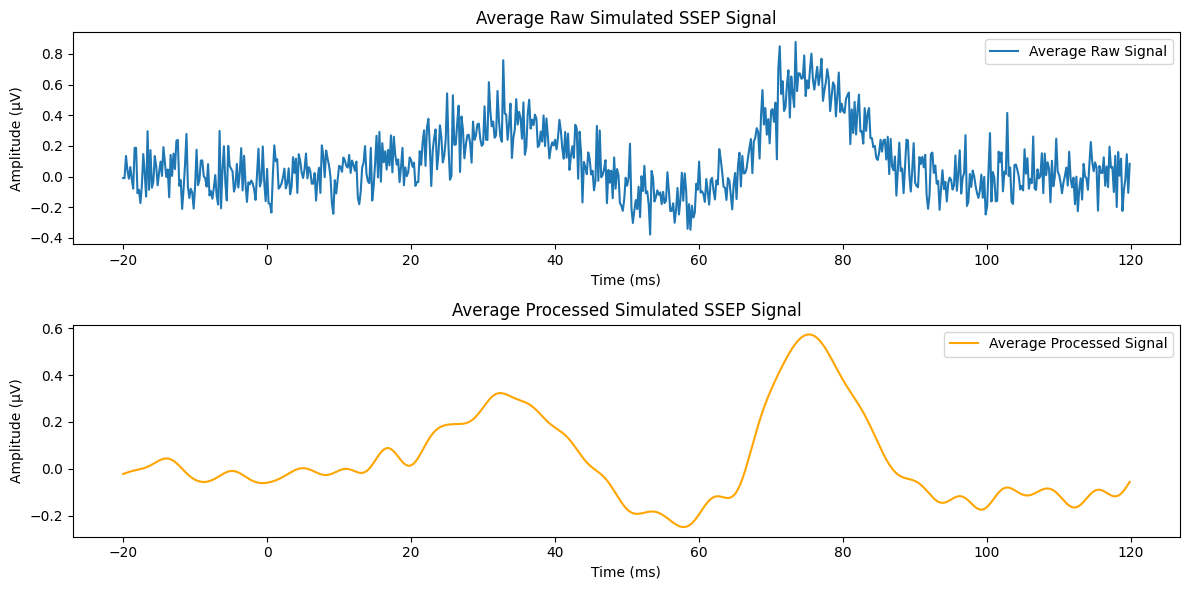

In [27]:
from dataclasses import dataclass, field
import numpy as np
import matplotlib.pyplot as plt

@dataclass
class Dataset:
    peaks: list
    fs: int = 5000
    tmin_ms: float = -20.0
    tmax_ms: float = 120.0
    latency_jitter_ms: float = 0.6
    amp_jitter_frac: float = 0.10
    noise_rms_uv: float = 0.0
    rng_seed: int | None = None

    trials: list = field(default_factory=list)
    trials_raw: list | None = None  # optional backup of original trials
    processing_log: list = field(default_factory=list)

    def generate_trials(self, n_trials=100):
        self.trials = []
        for i in range(n_trials):
            t_ms, sig = simulate_tibial_ssep_single_trial(
                fs=self.fs,
                tmin_ms=self.tmin_ms,
                tmax_ms=self.tmax_ms,
                peaks=self.peaks,
                latency_jitter_ms=self.latency_jitter_ms,
                amp_jitter_frac=self.amp_jitter_frac,
                noise_rms_uv=self.noise_rms_uv,
                rng_seed=(self.rng_seed + i) if self.rng_seed is not None else None,
            )
            self.trials.append((t_ms, sig))

        # reset processing history when regenerating
        self.trials_raw = None
        self.processing_log.clear()

    def average(self):
        if not self.trials:
            raise ValueError("No trials generated yet. Call generate_trials() first.")
        sigs = np.array([sig for _, sig in self.trials])
        avg_sig = np.mean(sigs, axis=0)
        return self.trials[0][0], avg_sig

    def preprocess(self, preprocessor: "Preprocessor", keep_raw: bool = True):
        if not self.trials:
            raise ValueError("No trials to preprocess. Call generate_trials() first.")

        if keep_raw and self.trials_raw is None:
            # store original trials only once (first preprocessing call)
            self.trials_raw = list(self.trials)

        self.trials = [(t_ms, preprocessor.apply(sig)) for t_ms, sig in self.trials]

        self.processing_log.append(
            {"fs": preprocessor.fs, "steps": preprocessor.describe()}
        )

    # define a method to plot the average signal across trials, with optional confidence intervals
    def plot_average(self, show_ci=False):
        t_ms, avg_sig = self.average()
        plt.figure(figsize=(10, 5))
        plt.plot(t_ms, avg_sig, label="Average Signal", color="blue")
        if show_ci:
            sigs = np.array([sig for _, sig in self.trials])
            ci = 1.96 * np.std(sigs, axis=0) / np.sqrt(len(sigs))
            plt.fill_between(t_ms, avg_sig - ci, avg_sig + ci, color="blue", alpha=0.3, label="95% CI")
        plt.title("Average Simulated SSEP Signal")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        #invert y axis to match typical SSEP plots
        plt.gca().invert_yaxis()
        plt.legend()
        plt.show()

    # define a method to plot all individual trials as a spaghetti plot
    def plot_trials(self):
        plt.figure(figsize=(10, 5))
        for t_ms, sig in self.trials:
            plt.plot(t_ms, sig, color="gray", alpha=0.5)
        plt.title("All Simulated SSEP Trials")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.gca().invert_yaxis()
        plt.show()

    # define a method to plot the average signal along with all individual trials
    def plot_average_with_trials(self):
        t_ms, avg_sig = self.average()
        plt.figure(figsize=(10, 5))
        for t_ms, sig in self.trials:
            plt.plot(t_ms, sig, color="gray", alpha=0.5)
        plt.plot(t_ms, avg_sig, label="Average Signal", color="blue", linewidth=2)
        plt.title("Average Simulated SSEP Signal with Individual Trials")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.gca().invert_yaxis()
        plt.legend()
        plt.show()

    # define a method to plot the raw and processed signals for a given trial index
    def plot_trial_comparison(self, trial_index=0):
        if self.trials_raw is None:
            raise ValueError("No raw trials stored. Call preprocess() with keep_raw=True first.")
        t_ms, raw_sig = self.trials_raw[trial_index]
        _, processed_sig = self.trials[trial_index]
        plt.figure(figsize=(12, 6))
        plt.subplot(2, 1, 1)
        plt.plot(t_ms, raw_sig, label="Raw Signal")
        plt.title(f"Raw Simulated SSEP Signal - Trial {trial_index}")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.legend()
        plt.subplot(2, 1, 2)
        plt.plot(t_ms, processed_sig, label="Processed Signal", color="orange")
        plt.title(f"Processed Simulated SSEP Signal - Trial {trial_index}")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # define a method to plot the average signal before and after preprocessing to visually confirm the effects of the processing steps
    def plot_average_comparison(self):
        if self.trials_raw is None:
            raise ValueError("No raw trials stored. Call preprocess() with keep_raw=True first.")
        t_ms, avg_raw = self.average_from_trials(self.trials_raw)
        _, avg_processed = self.average()
        plt.figure(figsize=(12, 6))
        plt.subplot(2, 1, 1)
        plt.plot(t_ms, avg_raw, label="Average Raw Signal")
        plt.title("Average Raw Simulated SSEP Signal")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.legend()
        plt.subplot(2, 1, 2)
        plt.plot(t_ms, avg_processed, label="Average Processed Signal", color="orange")
        plt.title("Average Processed Simulated SSEP Signal")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # helper method to compute average from a given list of trials (used for raw vs processed comparison)
    def average_from_trials(self, trials):
        sigs = np.array([sig for _, sig in trials])
        avg_sig = np.mean(sigs, axis=0)
        return trials[0][0], avg_sig



# sanity check for Dataset class
custom_peaks = [
    GaussianReboundPeak("P37", latency_ms=37.0, amp_uv=+.5, width_ms=10.0,
                        rebound_frac=.6, rebound_delay_ms=12, rebound_width_ms=12),
    Peak("P75", latency_ms=75.0, amp_uv=+.7, width_ms=6.0)
]
dataset = Dataset(peaks=custom_peaks, fs=5000, noise_rms_uv=2, rng_seed=42)
dataset.generate_trials(n_trials=300)

#print some info about the generated dataset
print(f"Generated {len(dataset.trials)} trials with {len(dataset.trials[0][0])} time points each.")
print(f"First trial time range: {dataset.trials[0][0][0]} ms to {dataset.trials[0][0][-1]} ms")
print(f"First trial signal snippet: {dataset.trials[0][1][:10]} ...")

# apply a simple preprocessing step to the dataset and check that it works without errors
preprocessor = Preprocessor(fs=dataset.fs)
preprocessor.add_lowpass(cutoff_hz=200.0, order=4)
preprocessor.add_bandpass(low_hz=1.0, high_hz=200.0, order=4)
dataset.preprocess(preprocessor)

# testing plotting methods for the dataset
dataset.plot_average(show_ci=True)
dataset.plot_trials()
dataset.plot_average_with_trials()
dataset.plot_trial_comparison(trial_index=0)
dataset.plot_average_comparison()




In this cell we will demonstrate how to use the `Dataset` and `Preprocessor` classes to generate a simulated dataset of tibial SSEP trials and apply a sequence of preprocessing steps to the data. We will create a dataset with a specified number of trials, and then use the `Preprocessor` class to apply both a low-pass filter and a band-pass filter to each trial's signal. Finally, we will visualize the raw and processed signals for a few example trials to illustrate the effects of the preprocessing steps. This will help us understand how the simulated data can be used to test and validate analysis pipelines, and how the preprocessing steps can affect the characteristics of the SSEP signals.

In [1]:
# Example usage
# Define some peaks for the simulation
custom_peaks = [
    GaussianReboundPeak("P37", latency_ms=37.0, amp_uv=+1.0, width_ms=5.0,
                        rebound_frac=.6, rebound_delay_ms=12, rebound_width_ms=12),
    Peak("P75", latency_ms=75.0, amp_uv=+1.2, width_ms=6.0)
]
# Create a dataset with the defined peaks
dataset = Dataset(peaks=custom_peaks, fs=5000, noise_rms_uv=0.5, rng_seed=42)
dataset.generate_trials(n_trials=10)
# Create a preprocessor and add some filters
preprocessor = Preprocessor(fs=dataset.fs)
preprocessor.add_lowpass(cutoff_hz=200.0, order=4)
preprocessor.add_bandpass(low_hz=1.0, high_hz=200.0, order=4)
# Apply preprocessing to the first trial and visualize
import matplotlib.pyplot as plt
t_ms, raw_sig = dataset.trials[0]
processed_sig = preprocessor.apply(raw_sig)
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t_ms, raw_sig, label="Raw Signal")
plt.title("Raw Simulated SSEP Signal")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(t_ms, processed_sig, label="Processed Signal", color="orange")
plt.title("Processed Simulated SSEP Signal")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'GaussianReboundPeak' is not defined

This cell we will generate n subjects worth of simulated tibial SSEP data, each with a specified number of trials. We will then apply the same preprocessing pipeline to each subject's dataset and visualize the average signal across subjects to confirm that the simulated peaks are present and that the preprocessing steps are working as expected. This will allow us to create a larger synthetic dataset that can be used for testing and validating analysis pipelines, and to ensure that the simulated data behaves in a realistic manner across multiple subjects.

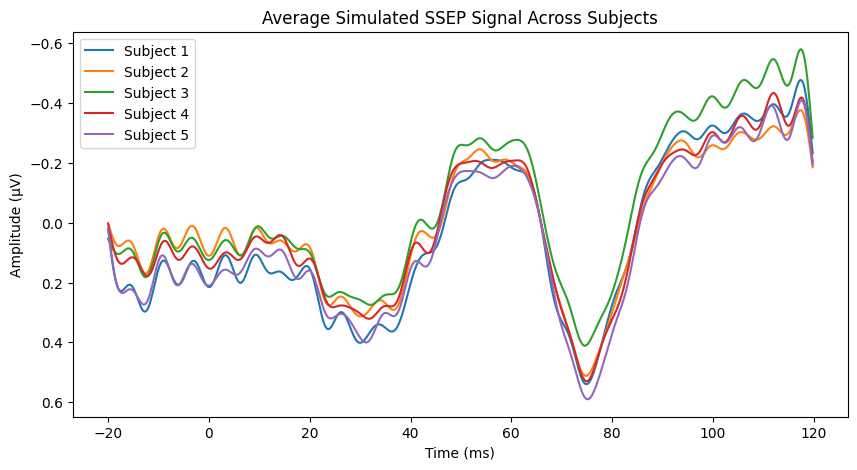

In [28]:
n=5  # number of subjects
subjects = []
for i in range(n):
    dataset = Dataset(peaks=custom_peaks, fs=5000, noise_rms_uv=0.5, rng_seed=42+i)
    dataset.generate_trials(n_trials=10)
    dataset.preprocess(preprocessor)
    subjects.append(dataset)
# Plot average signal across subjects
plt.figure(figsize=(10, 5))
for i, dataset in enumerate(subjects):
    t_ms, avg_sig = dataset.average()
    plt.plot(t_ms, avg_sig, label=f"Subject {i+1}")
plt.title("Average Simulated SSEP Signal Across Subjects")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.gca().invert_yaxis()
plt.legend()
plt.show()